In [37]:
%pip install pandas numpy spacy matplotlib plotly scikit-learn beautifulsoup4 nltk top2vec optuna optuna-dashboard

Note: you may need to restart the kernel to use updated packages.


In [38]:

import random
import time
import warnings

import numpy as np
import optuna
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from top2vec import Top2Vec

## Top2Vec

In [39]:
# Carga de datos
test = pd.read_csv("data/research-articles/test.csv")
train = pd.read_csv("data/research-articles/train.csv")

display(test.head())
display(train.head())

,ID,TITLE,ABSTRACT
0,20973,Closed-form Marginal Likelihood in Gamma-Poiss...,We present novel understandings of the Gamma...
1,20974,Laboratory mid-IR spectra of equilibrated and ...,Meteorites contain minerals from Solar Syste...
2,20975,Case For Static AMSDU Aggregation in WLANs,Frame aggregation is a mechanism by which mu...
3,20976,The $Gaia$-ESO Survey: the inner disk intermed...,Milky Way open clusters are very diverse in ...
4,20977,Witness-Functions versus Interpretation-Functi...,Proving that a cryptographic protocol is cor...


,ID,TITLE,ABSTRACT,Computer Science,Physics,Mathematics,Statistics,Quantitative Biology,Quantitative Finance
0,1,Reconstructing Subject-Specific Effect Maps,Predictive models allow subject-specific inf...,1,0,0,0,0,0
1,2,Rotation Invariance Neural Network,Rotation invariance and translation invarian...,1,0,0,0,0,0
2,3,Spherical polyharmonics and Poisson kernels fo...,We introduce and develop the notion of spher...,0,0,1,0,0,0
3,4,A finite element approximation for the stochas...,The stochastic Landau--Lifshitz--Gilbert (LL...,0,0,1,0,0,0
4,5,Comparative study of Discrete Wavelet Transfor...,Fourier-transform infra-red (FTIR) spectra o...,1,0,0,1,0,0


In [40]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20972 entries, 0 to 20971
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID                    20972 non-null  int64 
 1   TITLE                 20972 non-null  object
 2   ABSTRACT              20972 non-null  object
 3   Computer Science      20972 non-null  int64 
 4   Physics               20972 non-null  int64 
 5   Mathematics           20972 non-null  int64 
 6   Statistics            20972 non-null  int64 
 7   Quantitative Biology  20972 non-null  int64 
 8   Quantitative Finance  20972 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 1.4+ MB


In [41]:
train.dtypes

ID                       int64
TITLE                   object
ABSTRACT                object
Computer Science         int64
Physics                  int64
Mathematics              int64
Statistics               int64
Quantitative Biology     int64
Quantitative Finance     int64
dtype: object

In [42]:
# trabajamos con menos documentos, para facilitar la ejecución y bajar tiempos de procesamiento
train_small = train.sample(n=500, random_state=42)
documents = list(train_small.ABSTRACT.values) # utilizaremos solo la columan Abstract como los documentosnto

In [43]:
clean_text = documents
tokenized_texts = [doc.split() for doc in clean_text]
dictionary = Dictionary(tokenized_texts)
dictionary.filter_extremes(no_below=5, no_above=0.8)

In [44]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

def get_topic_words_from_top2vec(model, top_n=20):
    """
    Devuelve: topics_words: lista de listas (cada sublista = top_n palabras)
             topic_nums: lista de topic ids en el mismo orden
    """
    # número de topics detectados
    n_topics = model.get_num_topics()
    if n_topics == 0:
        return [], []
    # obtener topics en orden por tamaño: model.get_topics(n) devuelve los top n topics
    # devuelve (topic_words, word_scores, topic_nums)
    topic_words_all, word_scores_all, topic_nums = model.get_topics(n_topics)
    topics_words = []
    for words in topic_words_all:
        topics_words.append(words[:top_n])
    return topics_words, topic_nums


In [45]:
def objective(trial):
    """
    Busca hiperparámetros y devuelve coherencia c_v (a maximizar).
    NOTA: cada trial entrena Top2Vec y por tanto puede ser costoso.
    """
    # --- Hiperparámetros a explorar ---
    embedding_choice = trial.suggest_categorical("embedding_model",
                                                 ["doc2vec",
                                                  "universal-sentence-encoder",
                                                  "universal-sentence-encoder-multilingual",
                                                  "distiluse-base-multilingual-cased",
                                                  "all-MiniLM-L6-v2"])  # este último requiere sentence_transformers
    speed = trial.suggest_categorical("speed", ["fast-learn", "learn", "deep-learn"])
    workers = trial.suggest_int("workers", 1, 8)
    ngram_vocab = trial.suggest_categorical("ngram_vocab", [False, True])
    min_count = trial.suggest_int("min_count", 1, 5)   # filtra palabras raras
    # UMAP/HDBSCAN internals can be tweaked via kwargs but keep simple:
    umap_n_neighbors = trial.suggest_int("umap_n_neighbors", 5, 50)
    hdbscan_min_cluster_size = trial.suggest_int("hdbscan_min_cluster_size", 5, 50)
    top_n = trial.suggest_int("top_n", 8, 25)  # top words used to compute coherencia

    # --- Entrenar Top2Vec con esos hiperparámetros ---
    # Para evitar crash en modelos no instalados, envolver en try/except
    try:
        t0 = time.time()
        model = Top2Vec(
            documents=clean_text,
            embedding_model=embedding_choice,
            speed=speed,
            workers=workers,
            ngram_vocab=ngram_vocab,
            min_count=min_count,
            umap_args={"n_neighbors": umap_n_neighbors, "random_state": RANDOM_SEED},
            hdbscan_args={"min_cluster_size": hdbscan_min_cluster_size},
            verbose=False
        )
        elapsed = time.time() - t0
    except Exception as e:
        # Si falla (p. ej. embedding no instalado), penalizamos mostrando el error
        trial.set_user_attr("error", str(e))
        return -1e6

    # Extraer topics y sus palabras
    topic_words_list, topic_nums = get_topic_words_from_top2vec(model, top_n=top_n)

    # Si no hay topics (p. ej. todo outliers), penalizar
    if len(topic_words_list) == 0:
        trial.set_user_attr("n_topics", 0)
        return -1e6

    # Calcular coherencia c_v con gensim (usa tokenized_texts y dictionary)
    try:
        cm = CoherenceModel(topics=topic_words_list, texts=tokenized_texts, dictionary=dictionary, coherence='c_v')
        coherence = cm.get_coherence()
    except Exception as e:
        trial.set_user_attr("coherence_error", str(e))
        return -1e6

    # Algunos metadatos para analizar luego
    trial.set_user_attr("elapsed_s", elapsed)
    trial.set_user_attr("n_topics", len(topic_words_list))
    trial.set_user_attr("embedding_choice", embedding_choice)

    return float(coherence)

In [46]:
def run_optuna_top2vec(n_trials=20):
    sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
    study = optuna.create_study(direction="maximize", sampler=sampler)
    print("Iniciando Optuna para Top2Vec. n_trials =", n_trials)
    study.optimize(objective, n_trials=n_trials)

    print("Mejor coherencia:", study.best_value)
    print("Mejores hiperparámetros:", study.best_params)

    # Reentrenar el mejor modelo sobre todo el corpus (con parámetros obtenidos)
    best = study.best_params
    print("Reentrenando Top2Vec con los mejores hiperparámetros...")
    best_model = Top2Vec(
        documents=clean_text,
        embedding_model=best["embedding_model"],
        speed=best["speed"],
        workers=best["workers"],
        ngram_vocab=best["ngram_vocab"],
        min_count=best["min_count"],
        umap_args={"n_neighbors": best["umap_n_neighbors"], "random_state": RANDOM_SEED},
        hdbscan_args={"min_cluster_size": best["hdbscan_min_cluster_size"]},
        verbose=True
    )

    # Extraer topics del mejor modelo y construir DataFrame
    best_topic_words, best_topic_nums = get_topic_words_from_top2vec(best_model, top_n=20)
    df_topics = pd.DataFrame({
        "topic_num": best_topic_nums,
        "top_words": [", ".join(words) for words in best_topic_words]
    })

    # Devolver estudio, modelo y df
    return study, best_model, df_topics, study.trials_dataframe()

In [47]:
study, top2vec_best_model, df_topics_best, trials_df = run_optuna_top2vec(n_trials=20)
display(trials_df[["number","value","state","params_embedding_model","params_speed","params_workers","params_ngram_vocab","params_min_count","params_umap_n_neighbors","params_hdbscan_min_cluster_size"]])

[I 2025-12-02 22:39:26,246] A new study created in memory with name: no-name-04b142ec-5c3b-4305-93f1-5af92215f54d
[I 2025-12-02 22:39:26,248] Trial 0 finished with value: -1000000.0 and parameters: {'embedding_model': 'universal-sentence-encoder', 'speed': 'deep-learn', 'workers': 5, 'ngram_vocab': False, 'min_count': 5, 'umap_n_neighbors': 43, 'hdbscan_min_cluster_size': 14, 'top_n': 11}. Best is trial 0 with value: -1000000.0.
[I 2025-12-02 22:39:26,250] Trial 1 finished with value: -1000000.0 and parameters: {'embedding_model': 'universal-sentence-encoder-multilingual', 'speed': 'fast-learn', 'workers': 3, 'ngram_vocab': True, 'min_count': 1, 'umap_n_neighbors': 28, 'hdbscan_min_cluster_size': 32, 'top_n': 8}. Best is trial 0 with value: -1000000.0.


Iniciando Optuna para Top2Vec. n_trials = 20


C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'

2025-12-02 22:39:26,378 - top2vec - INFO - Downloading all-MiniLM-L6-v2 model
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

[I 2025-12-02 22:39:40,636] Trial 2 finished with value: 0.2984755745335389 and parameters: {'embedding_model': 'all-MiniLM-L6-v2', 'speed': 'fas

Mejor coherencia: 0.5009529481191868
Mejores hiperparámetros: {'embedding_model': 'distiluse-base-multilingual-cased', 'speed': 'learn', 'workers': 2, 'ngram_vocab': False, 'min_count': 4, 'umap_n_neighbors': 32, 'hdbscan_min_cluster_size': 38, 'top_n': 23}
Reentrenando Top2Vec con los mejores hiperparámetros...


2025-12-02 22:43:50,056 - top2vec - INFO - Creating joint document/word embedding
2025-12-02 22:44:07,924 - top2vec - INFO - Creating lower dimension embedding of documents
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

2025-12-02 22:44:08,584 - top2vec - INFO - Finding dense areas of documents
C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

C:\Users\zeldan\anaconda3\envs\tfg-topics2\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

2025-12-02 22:44:08,593 - top2vec - INFO - Finding topics


,number,value,state,params_embedding_model,params_speed,params_workers,params_ngram_vocab,params_min_count,params_umap_n_neighbors,params_hdbscan_min_cluster_size
0,0,-1000000.000000,COMPLETE,universal-sentence-encoder,deep-learn,5,False,5,43,14
1,1,-1000000.000000,COMPLETE,universal-sentence-encoder-multilingual,fast-learn,3,True,1,28,32
2,2,0.298476,COMPLETE,all-MiniLM-L6-v2,fast-learn,6,False,3,6,46
3,3,-1000000.000000,COMPLETE,doc2vec,fast-learn,8,True,1,14,7
4,4,-1000000.000000,COMPLETE,universal-sentence-encoder-multilingual,deep-learn,1,False,1,5,42
5,5,-1000000.000000,COMPLETE,universal-sentence-encoder,fast-learn,1,True,4,34,45
6,6,0.422336,COMPLETE,all-MiniLM-L6-v2,learn,1,False,4,19,28
7,7,-1000000.000000,COMPLETE,universal-sentence-encoder-multilingual,deep-learn,7,True,5,13,46
8,8,-1000000.000000,COMPLETE,universal-sentence-encoder,deep-learn,1,False,2,10,20
9,9,0.397373,COMPLETE,all-MiniLM-L6-v2,fast-learn,3,False,4,28,7


In [48]:
# Mostrar resultados
display(df_topics_best.head(30))

,topic_num,top_words
0,0,"algorithmic, algorithm, algorithms, geometric,..."
1,1,"neutrino, gravitational, quantum, physics, neu..."


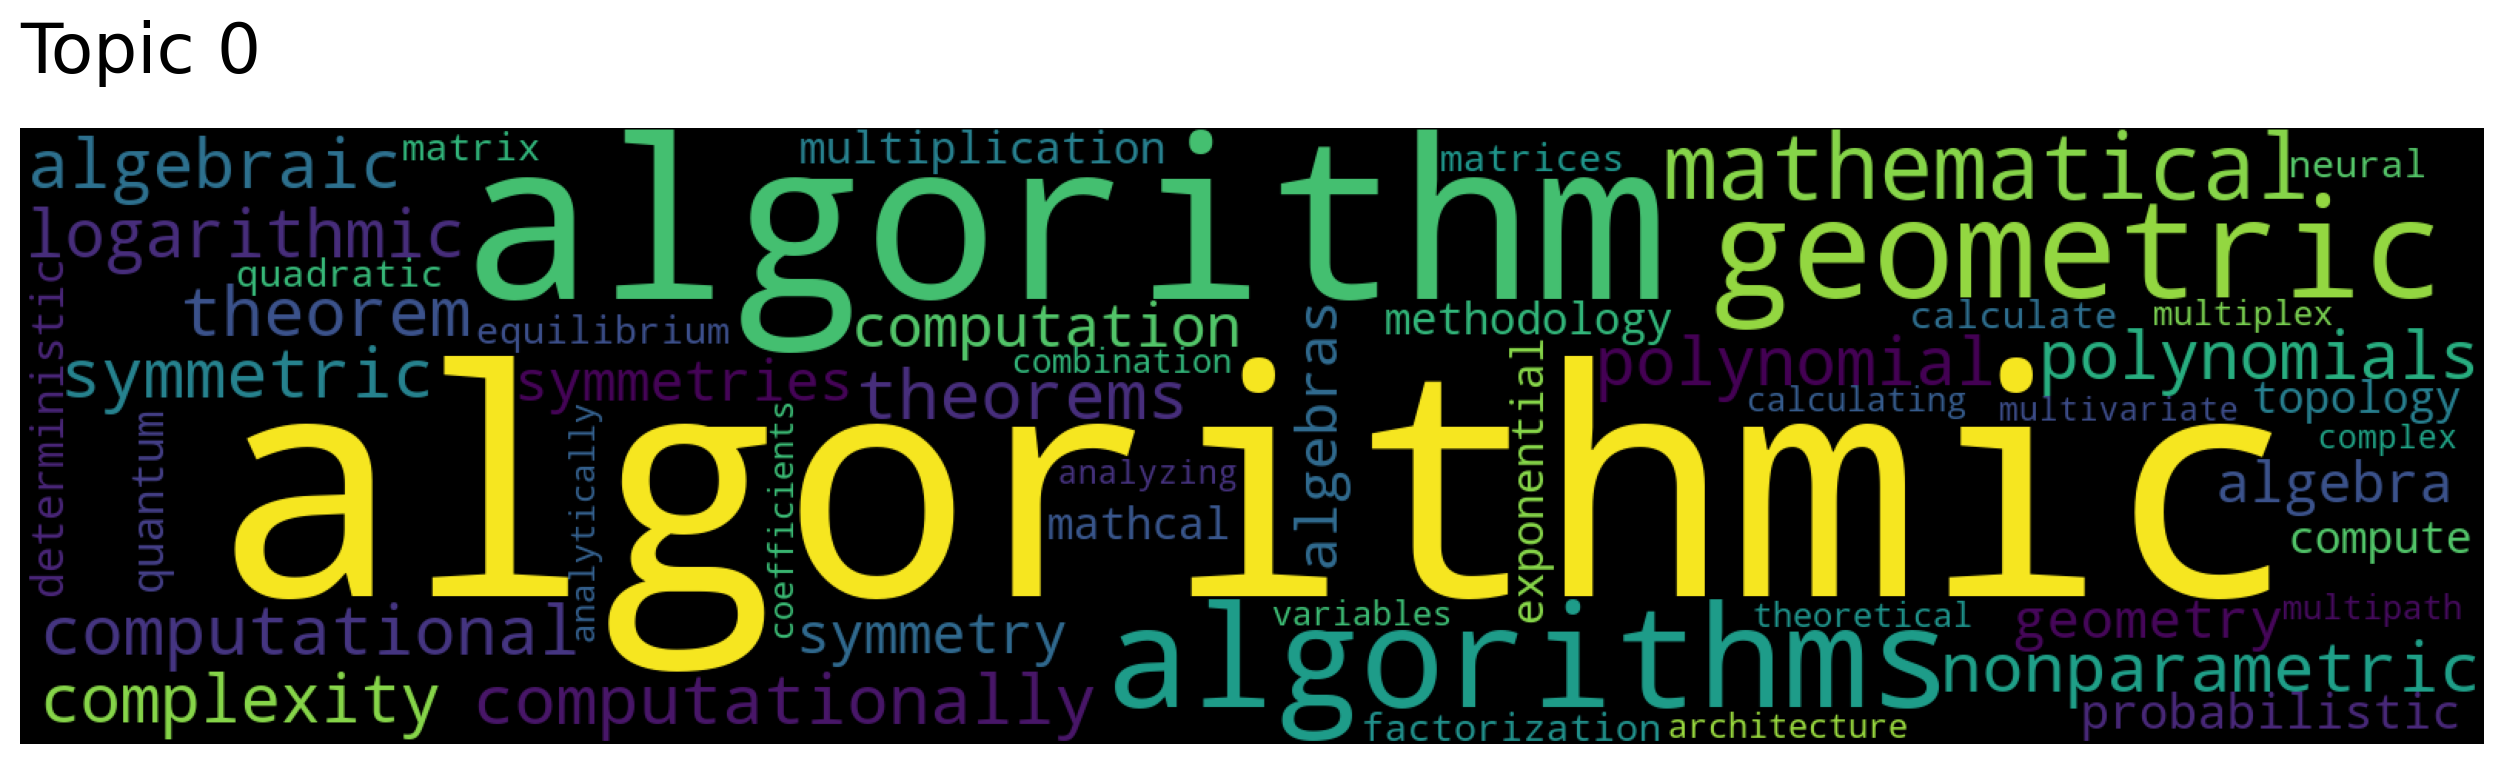

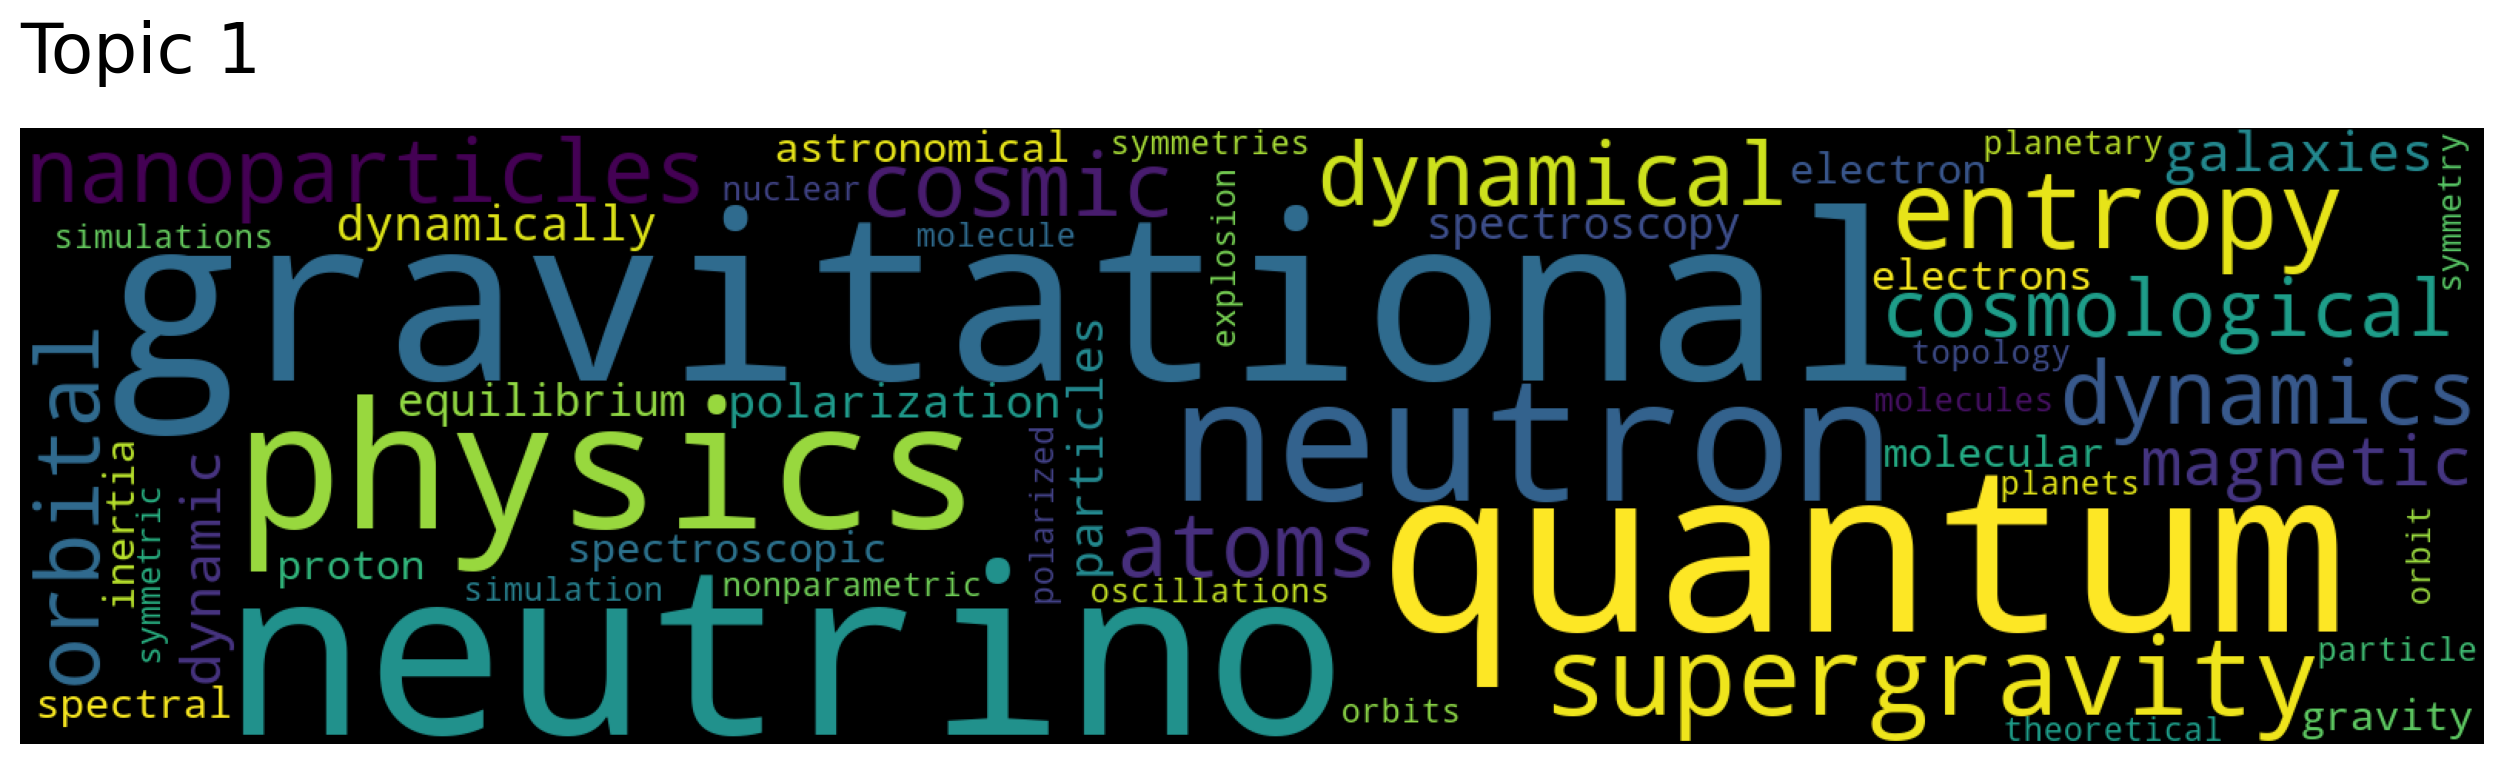

In [49]:
warnings.filterwarnings("ignore", category=DeprecationWarning, module="matplotlib")
for i in range(top2vec_best_model.get_num_topics()):
    top2vec_best_model.generate_topic_wordcloud(i)